# Fig 2

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
import os

In [2]:
final_results_dir = '/home/nuttidalab/Documents/spikeRNN/notebooks/CoSyne/figs/'

In [3]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [4]:
# load a model to get trial times

for models_type in models_types:
    # load list of models
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    for n_model, model_fname in enumerate(model_list):
        
        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        
        break
    break

Total: 41 good_models models
Loading model 1/41...


In [5]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

# plotting info
stim1_on_idx = np.where(t <= stim1_on)[0][-1]
stim1_off_idx = np.where(t <= stim1_off)[0][-1]
stim2_on_idx = np.where(t <= stim2_on)[0][-1]
stim2_off_idx = np.where(t <= stim2_off)[0][-1]


In [6]:
# adjust for x-axis labels
t_skip = 15

## 2A. 8-line plot

Plotting theta power for both good and bad models...
Plotting alpha power for both good and bad models...
Plotting beta power for both good and bad models...
Plotting gamma1 power for both good and bad models...
Plotting gamma2 power for both good and bad models...


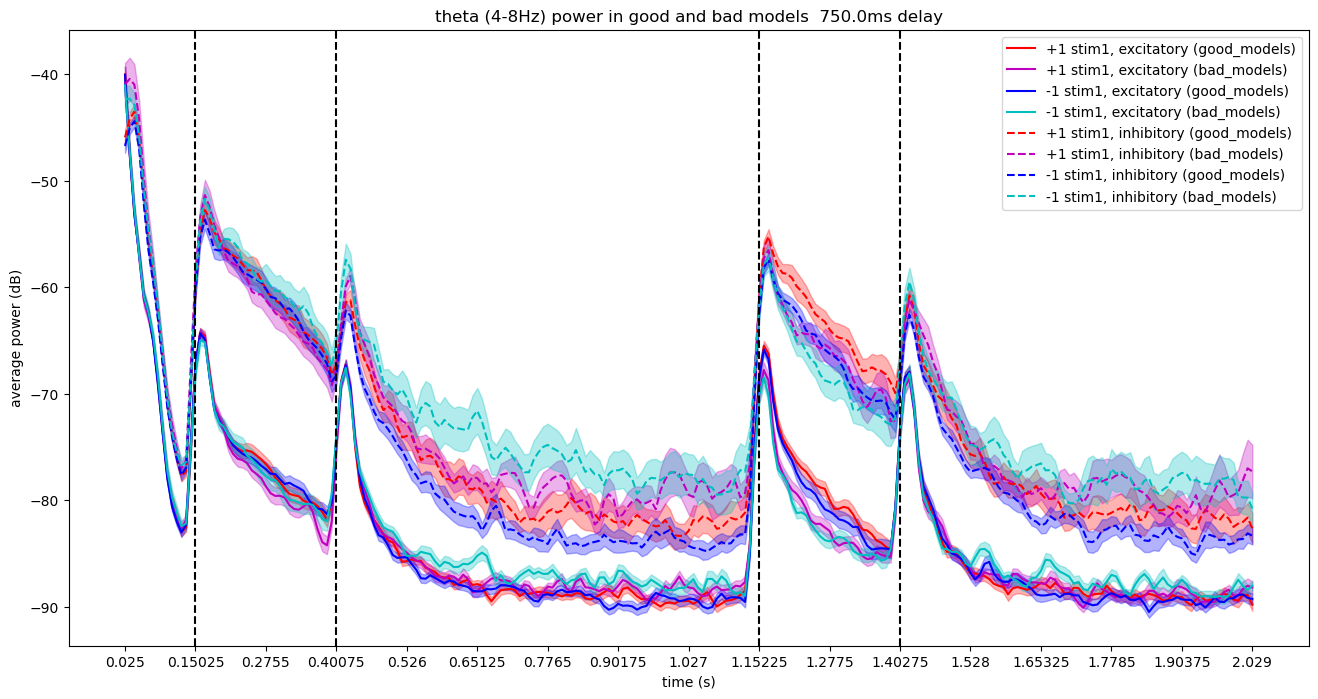

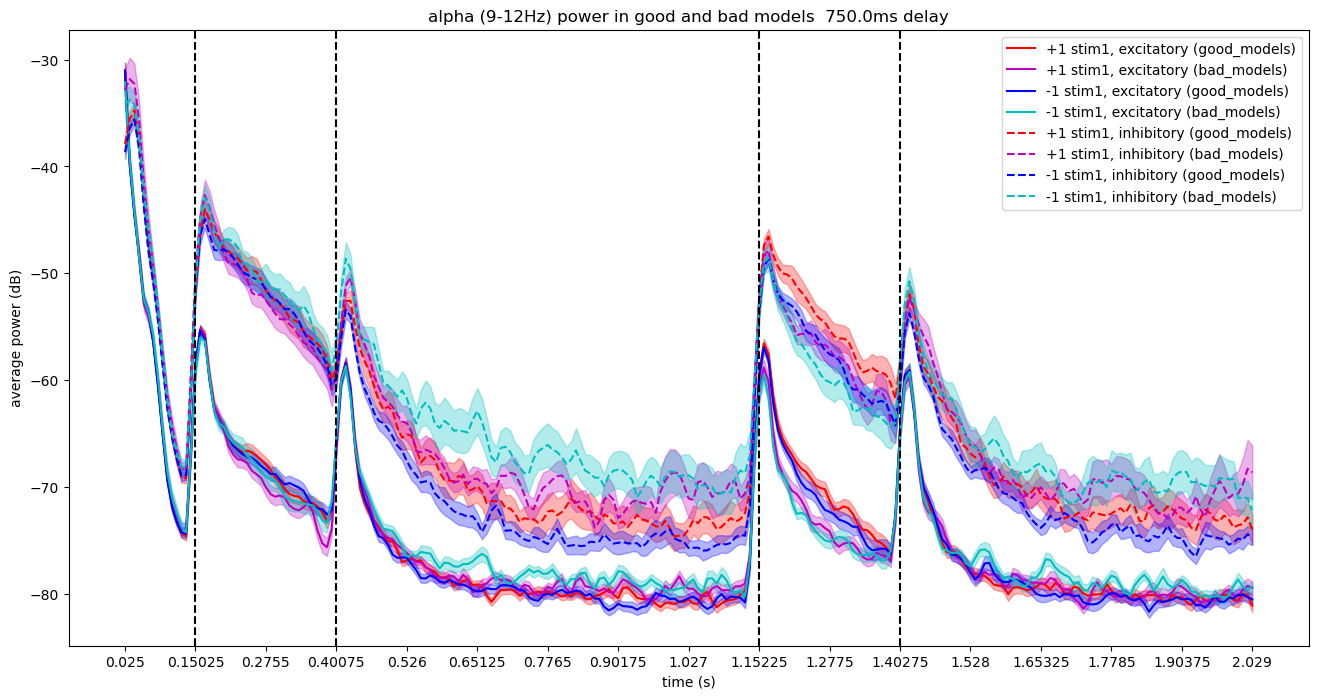

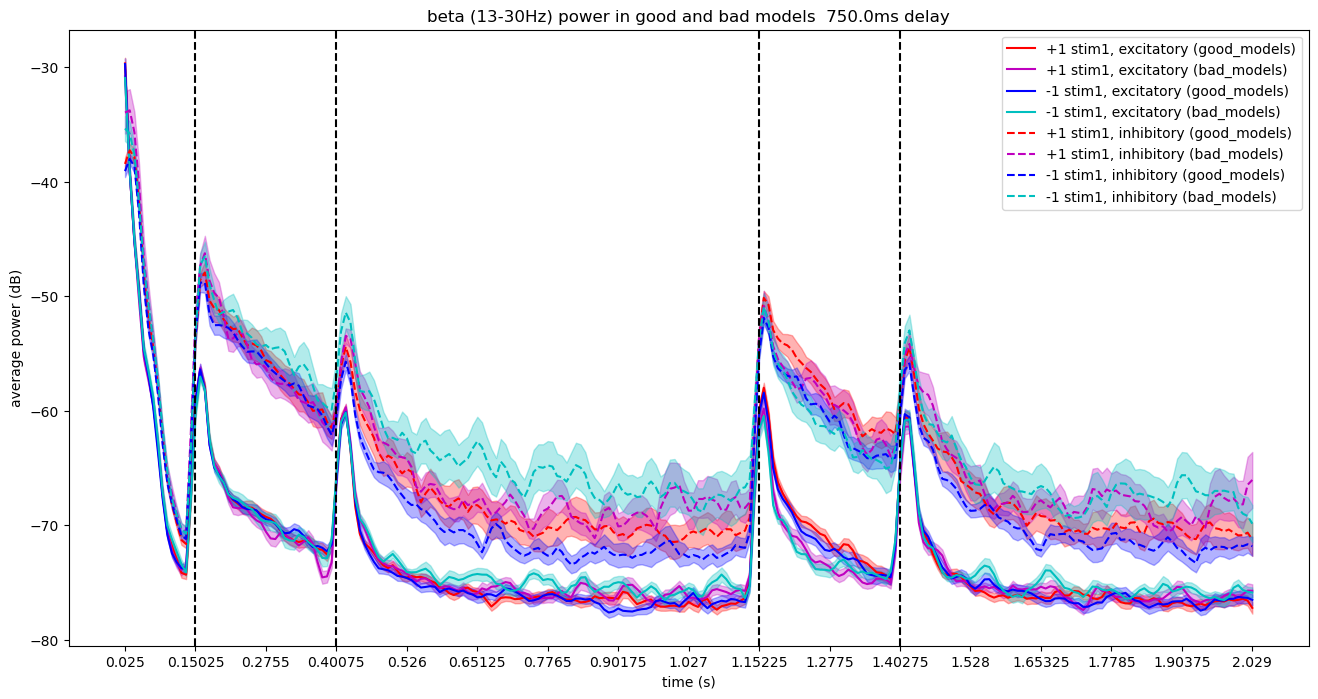

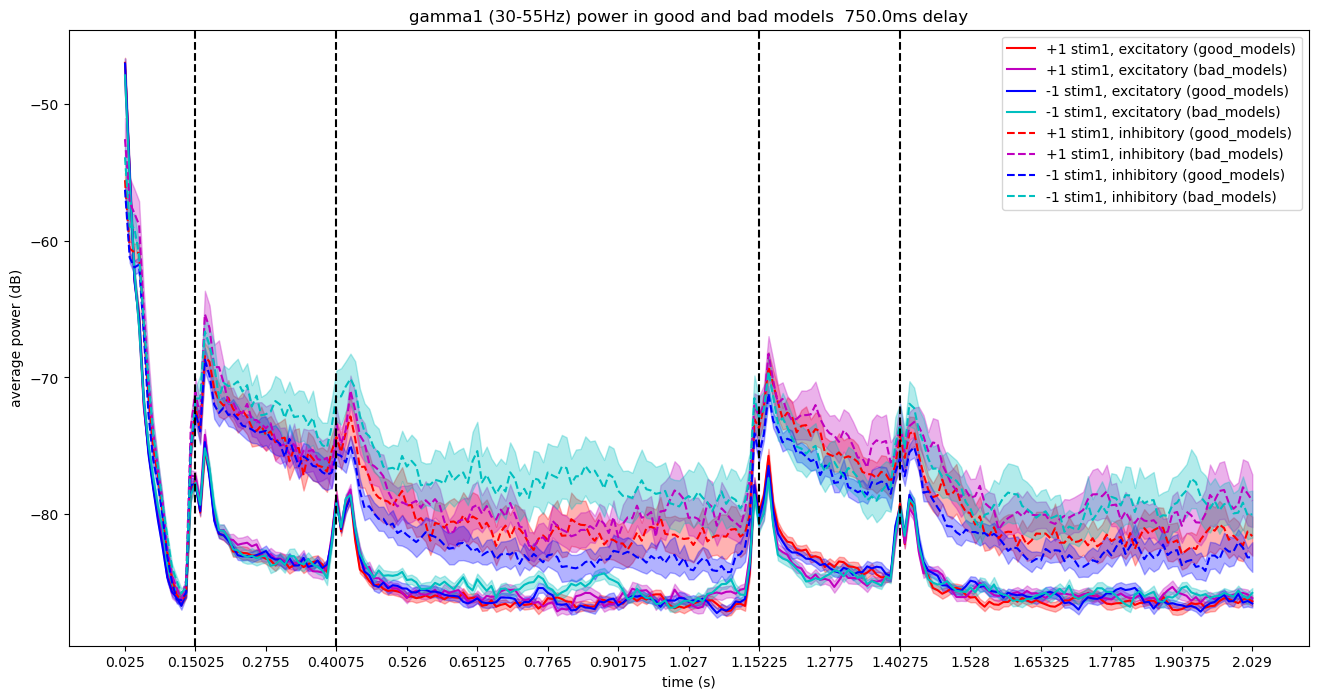

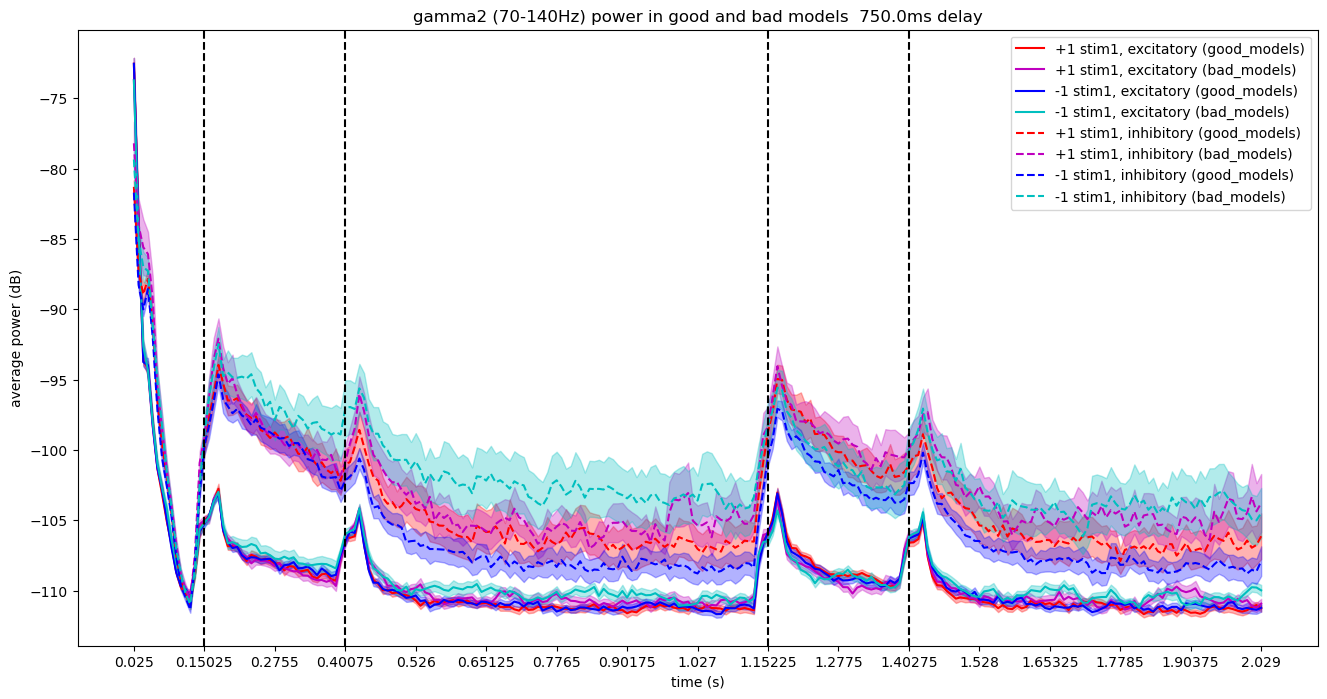

In [7]:
# plot and save 8-in-1 plot

models_bandmeans = []
models_bandsems = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# plot good and bad on the same plot
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    print(f'Plotting {power} power for both good and bad models...')
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    plt.figure(figsize=(16,8))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, models_type in enumerate(models_types):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                plt.plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                plt.fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
    plt.axvline(x=stim1_on_idx, color='k', linestyle='--')
    plt.axvline(x=stim1_off_idx, color='k', linestyle='--')
    plt.axvline(x=stim2_on_idx, color='k', linestyle='--')
    plt.axvline(x=stim2_off_idx, color='k', linestyle='--')
    plt.xlabel('time (s)')
    plt.ylabel('average power (dB)')
    plt.xticks(range(len(t))[::t_skip],t[::t_skip])
    if len(lesion_name[0]) > 0:
        lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
    else:
        lesion_name_title = ''
    plt.title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
    plt.legend()
    plt.savefig(f'{final_results_dir}2A_{power}_diff_good+bad{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


## 2B, 2C. Comparing exc vs inh

In [7]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

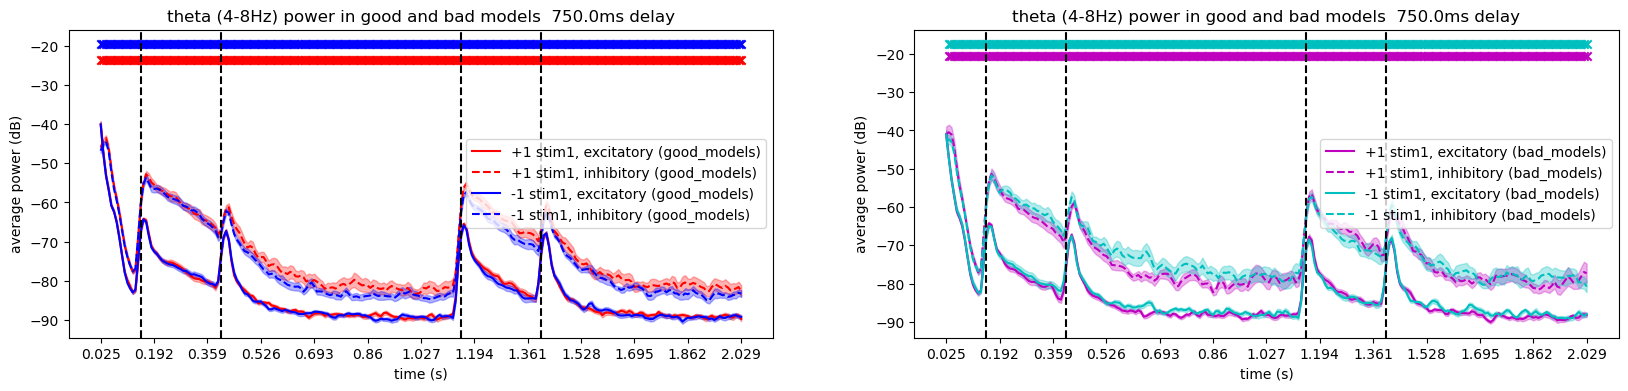

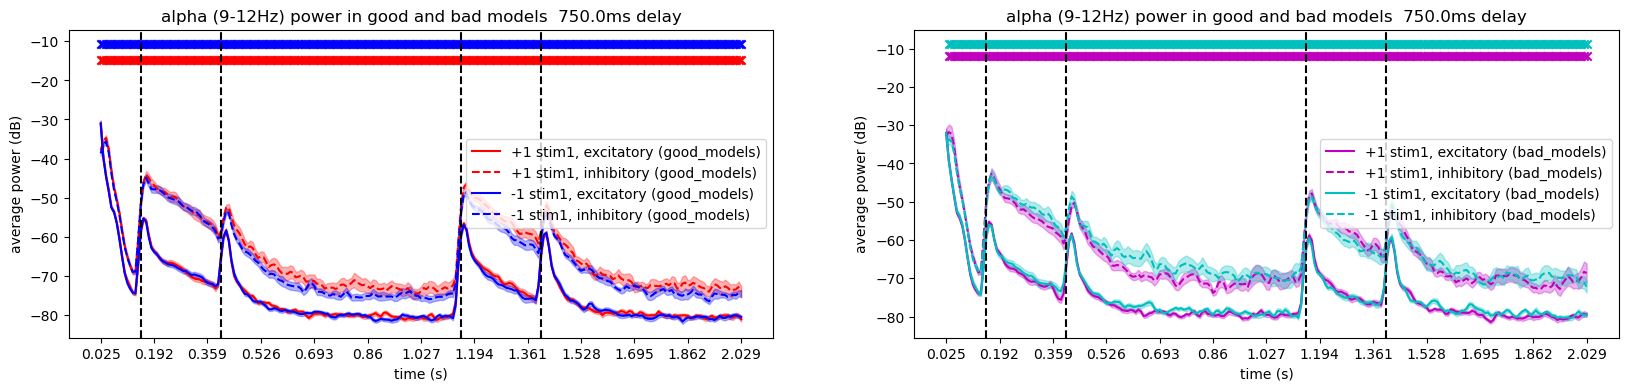

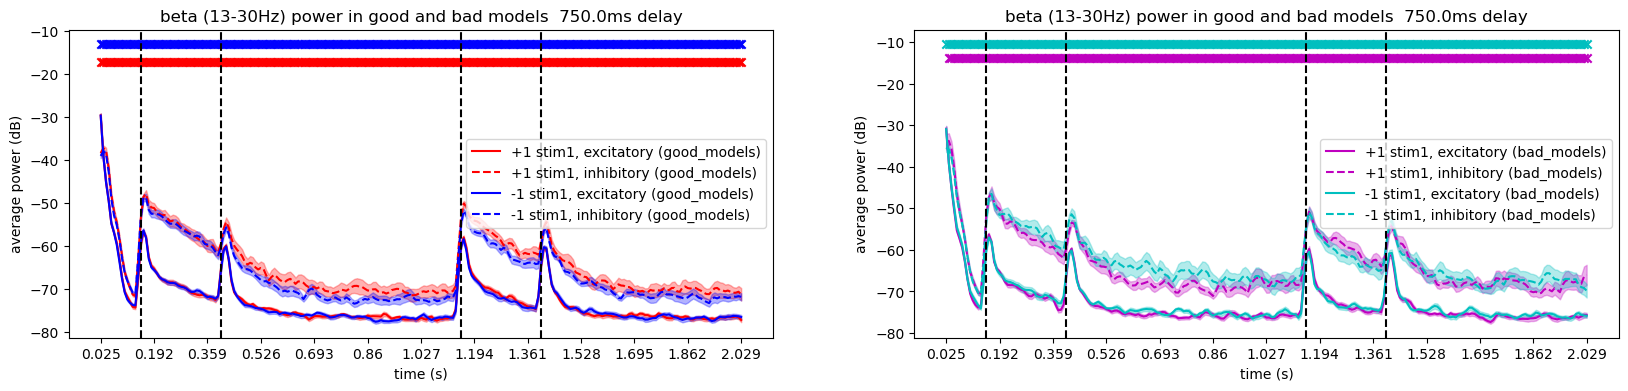

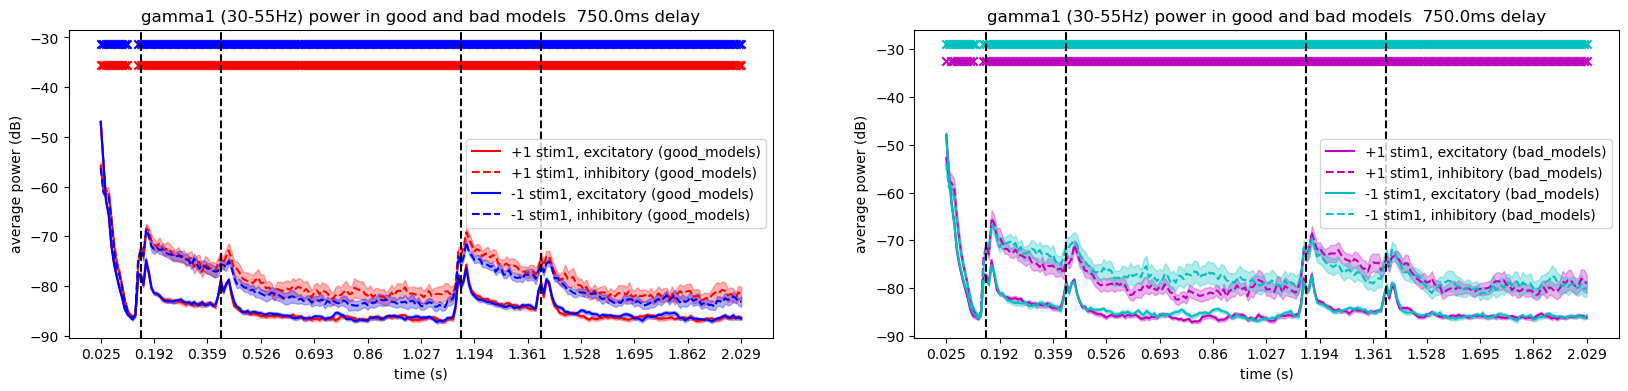

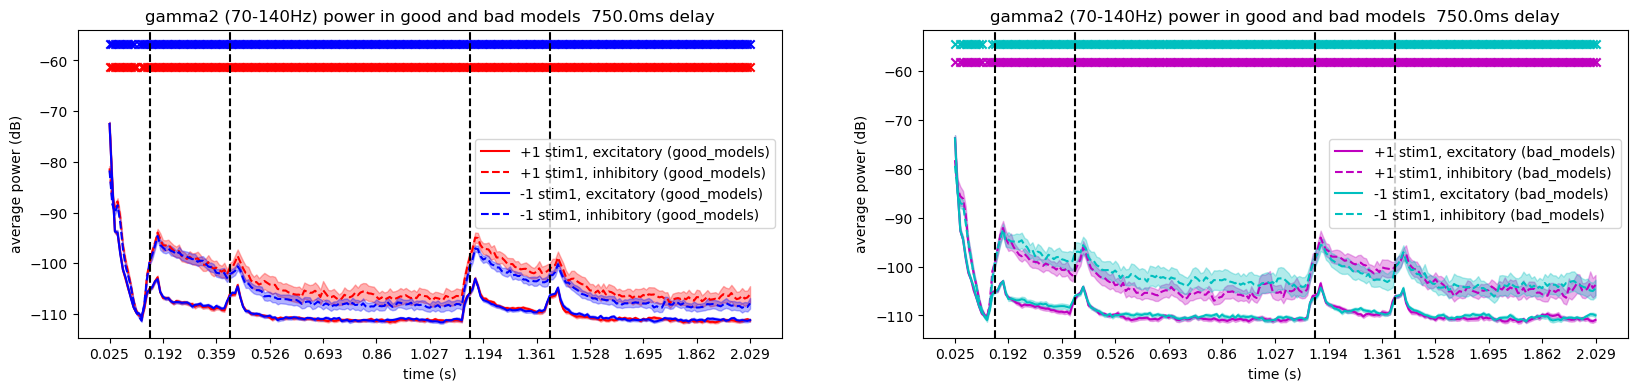

In [10]:
# plot good and bad models separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_bandpdiff = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
                                                        all_powers[k][1][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            # significant_timepoints = time_vector[pdiff < 0.05]
            band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    for m, models_type in enumerate(models_types):
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[m].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[m].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            significant_timepoints = time_vector[models_bandpdiff[m][i,k,:] < 0.05]
            axs[m].scatter(significant_timepoints, np.zeros_like(significant_timepoints)+np.max(band_mean)+20+k*5, color=colors[m][k], label='_nolegend_', marker='x')

        axs[m].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[m].set_xlabel('time (s)')
        axs[m].set_ylabel('average power (dB)')
        axs[m].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[m].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[m].legend()
    plt.savefig(f'{final_results_dir}2B_{power}_diff_exc+inh{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


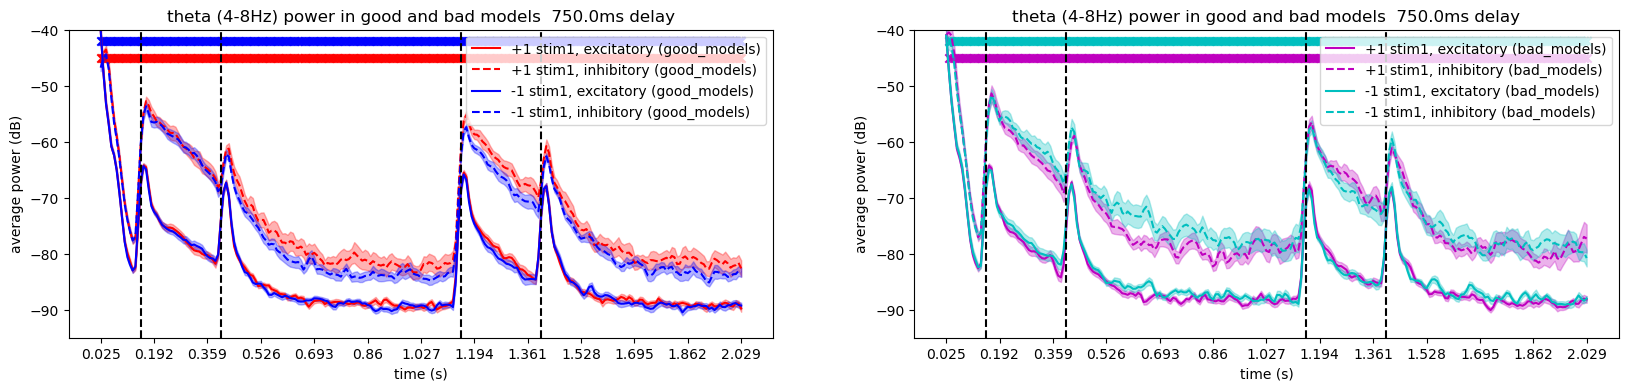

In [11]:
# just theta

# plot good and bad models separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_bandpdiff = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
                                                        all_powers[k][1][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            # significant_timepoints = time_vector[pdiff < 0.05]
            band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
            continue
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    for m, models_type in enumerate(models_types):
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[m].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[m].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            significant_timepoints = time_vector[models_bandpdiff[m][i,k,:] < 0.05]
            axs[m].scatter(significant_timepoints, np.zeros_like(significant_timepoints)-45+k*3, color=colors[m][k], label='_nolegend_', marker='x')

        axs[m].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[m].set_xlabel('time (s)')
        axs[m].set_ylabel('average power (dB)')
        axs[m].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        axs[m].set_ylim([-95, -40])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[m].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[m].legend()
    plt.savefig(f'{final_results_dir}2B_{power}_diff_exc+inh{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


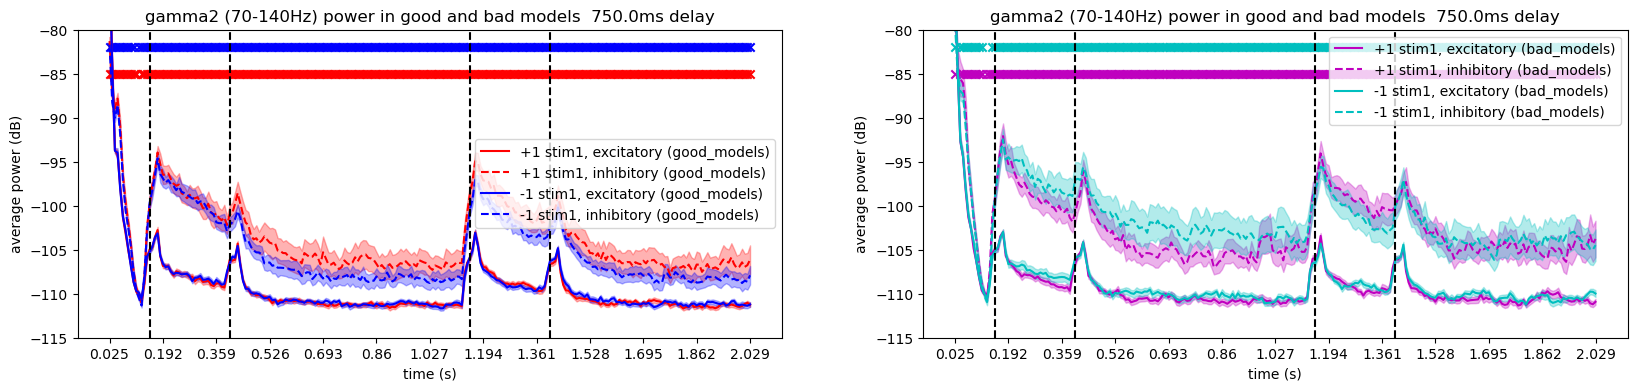

In [12]:
# just gamma

# plot good and bad models separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_bandpdiff = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
                                                        all_powers[k][1][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            # significant_timepoints = time_vector[pdiff < 0.05]
            band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
            continue
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    for m, models_type in enumerate(models_types):
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[m].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[m].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            significant_timepoints = time_vector[models_bandpdiff[m][i,k,:] < 0.05]
            axs[m].scatter(significant_timepoints, np.zeros_like(significant_timepoints)-85+k*3, color=colors[m][k], label='_nolegend_', marker='x')

        axs[m].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[m].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[m].set_xlabel('time (s)')
        axs[m].set_ylabel('average power (dB)')
        axs[m].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        axs[m].set_ylim([-115, -80])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[m].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[m].legend()
    plt.savefig(f'{final_results_dir}2B_{power}_diff_exc+inh{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


## 2D, 2E. Comparing good vs bad

In [3]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [9]:
# load a model to get trial times

for models_type in models_types:
    # load list of models
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    for n_model, model_fname in enumerate(model_list):
        
        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        
        break
    break

Total: 41 good_models models
Loading model 1/41...


In [10]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

# plotting info
stim1_on_idx = np.where(t <= stim1_on)[0][-1]
stim1_off_idx = np.where(t <= stim1_off)[0][-1]
stim2_on_idx = np.where(t <= stim2_on)[0][-1]
stim2_off_idx = np.where(t <= stim2_off)[0][-1]


In [7]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

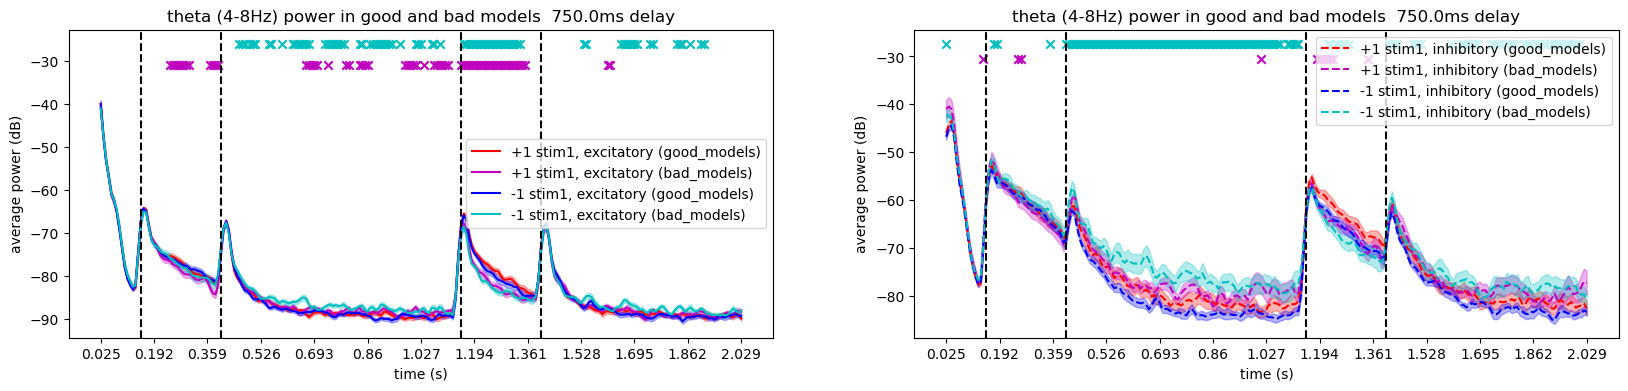

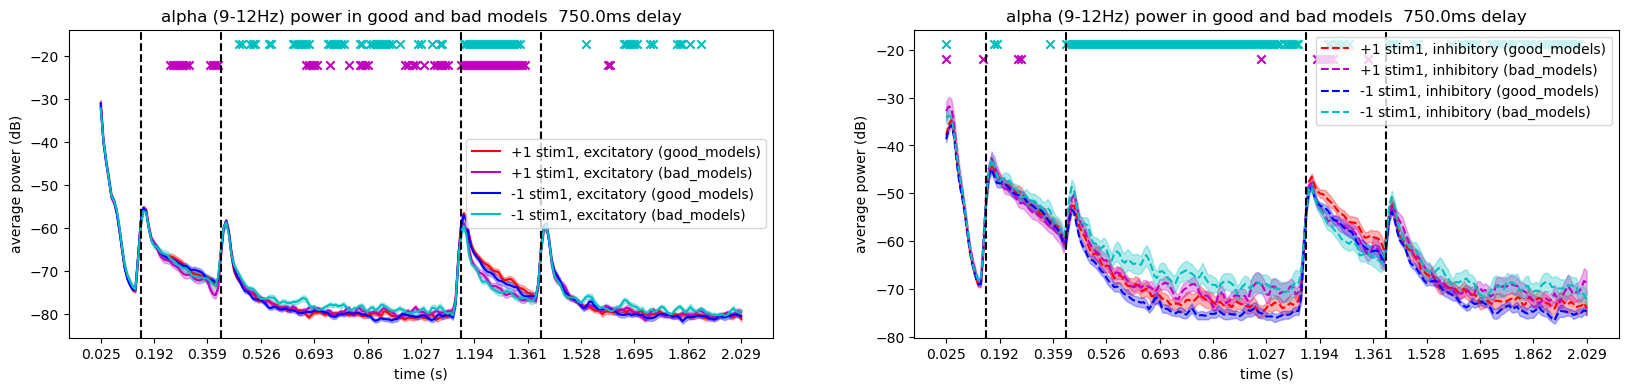

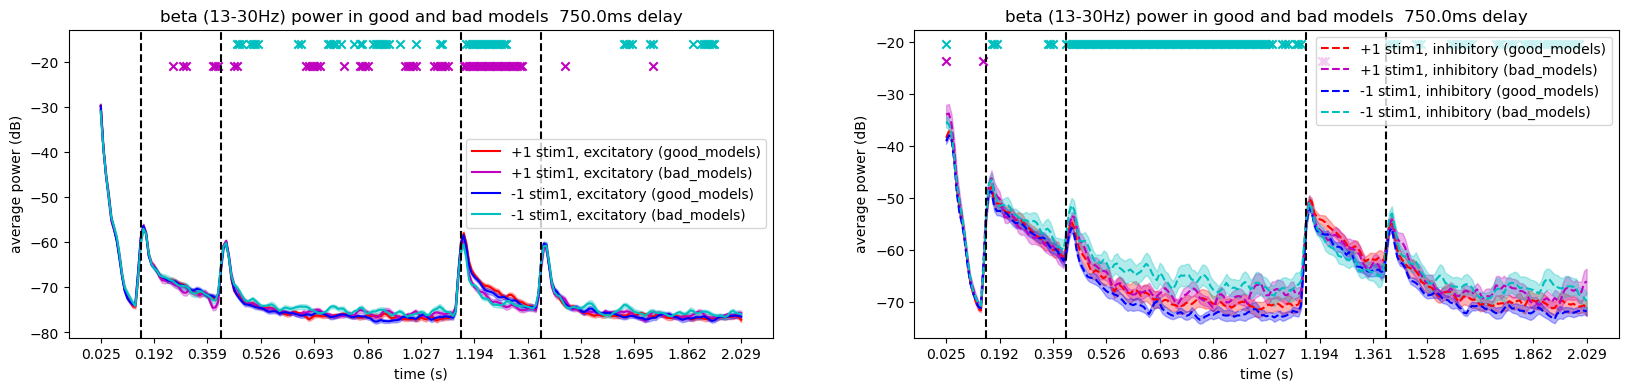

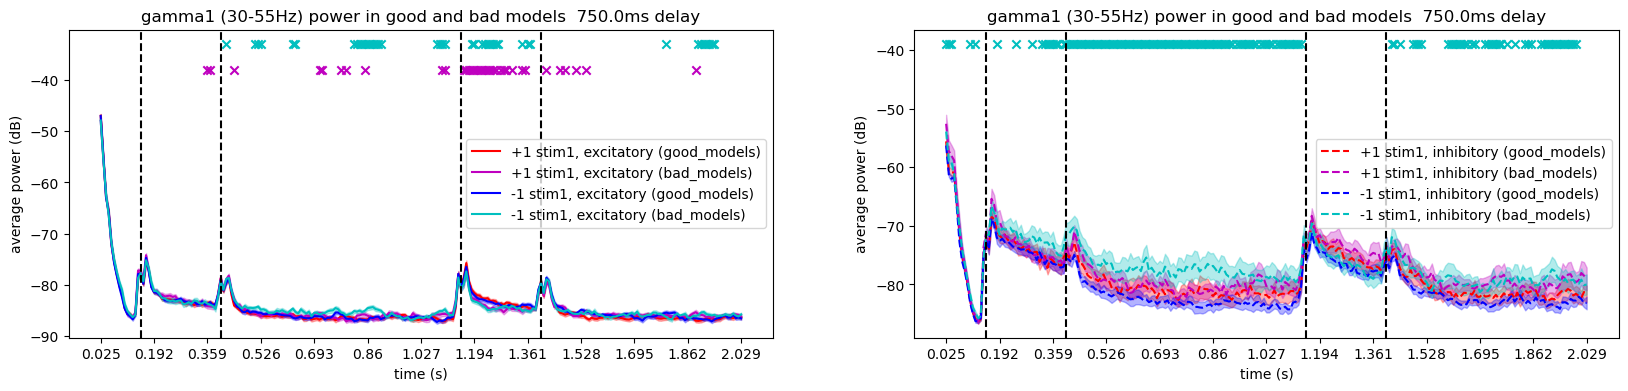

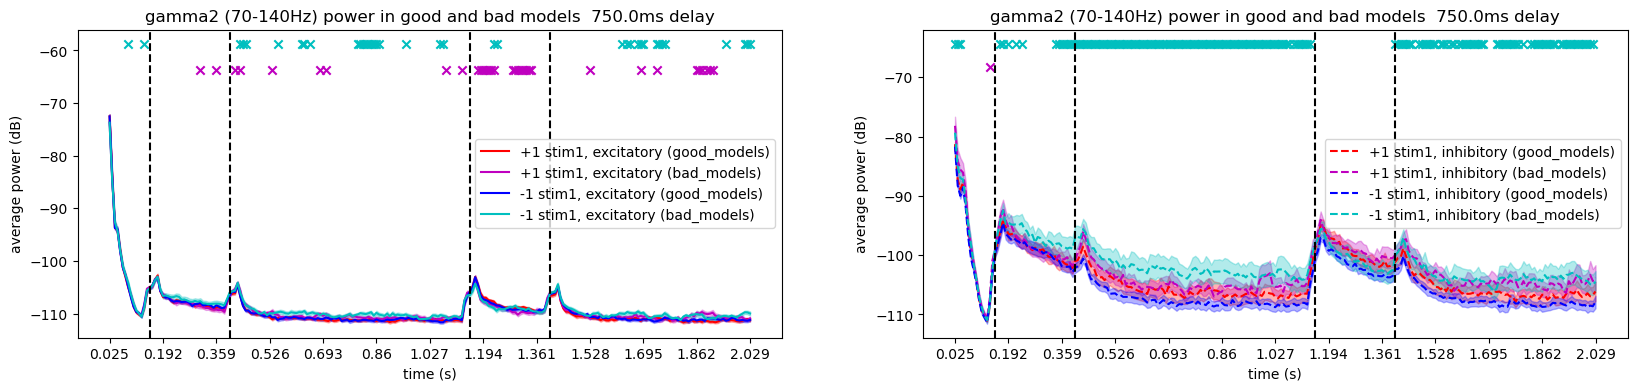

In [52]:
# plot exc and inh neurons separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)
    

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            # _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
            #                                             all_powers[k][1][:,i,:], 
            #                                             nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    # models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    
    
    # band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, models_type in enumerate(models_types):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[j].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[j].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model, same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            axs[j].scatter(significant_timepoints, np.zeros_like(significant_timepoints)+np.max(band_mean)+10+k*5, color=colors[m][k], label='_nolegend_', marker='x')

        axs[j].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[j].set_xlabel('time (s)')
        axs[j].set_ylabel('average power (dB)')
        axs[j].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[j].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[j].legend()
    plt.savefig(f'{final_results_dir}2D_{power}_diff_good+bad{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


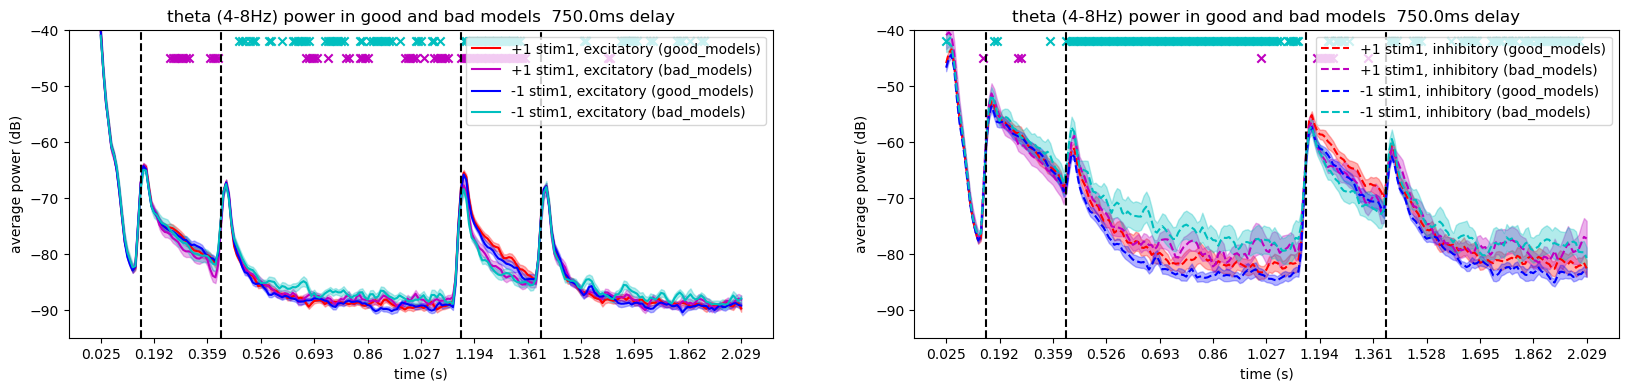

In [15]:
# plot just theta

# plot exc and inh neurons separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)
    
    n_models = all_powers_pos_exc.shape[0]
    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot
    t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))
    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            # _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
            #                                             all_powers[k][1][:,i,:], 
            #                                             nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    # models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
            continue
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    
    
    # band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, models_type in enumerate(models_types):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[j].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[j].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model, same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            axs[j].scatter(significant_timepoints, np.zeros_like(significant_timepoints)-45+k*3, color=colors[m][k], label='_nolegend_', marker='x')

        axs[j].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[j].set_xlabel('time (s)')
        axs[j].set_ylabel('average power (dB)')
        axs[j].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        axs[j].set_ylim([-95,-40])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[j].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[j].legend()
    plt.savefig(f'{final_results_dir}2D_{power}_diff_good+bad{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


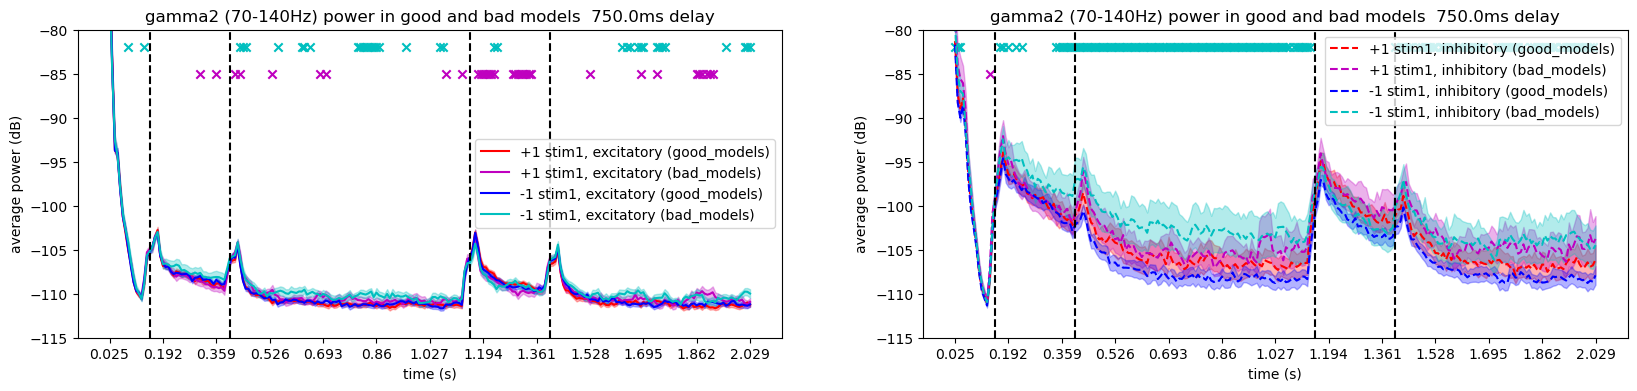

In [13]:
# plot just gamma2

# plot exc and inh neurons separately, for each power band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)
    
    n_models = all_powers_pos_exc.shape[0]
    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Plot
    t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))
    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

            # _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
            #                                             all_powers[k][1][:,i,:], 
            #                                             nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)
    # models_bandpdiff.append(band_pdiff)

t_skip = 20

# plot good and bad on separate subplots for each frequency
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
            continue
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1, 2, figsize=(20,4))
    
    
    # band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, models_type in enumerate(models_types):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                axs[j].plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[j].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model, same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            axs[j].scatter(significant_timepoints, np.zeros_like(significant_timepoints)-85+k*3, color=colors[m][k], label='_nolegend_', marker='x')

        axs[j].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[j].set_xlabel('time (s)')
        axs[j].set_ylabel('average power (dB)')
        axs[j].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        axs[j].set_ylim([-115,-80])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[j].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        axs[j].legend()
    plt.savefig(f'{final_results_dir}2D_{power}_diff_good+bad{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


## 2F. Behavior performance across all models as a function of delay duration

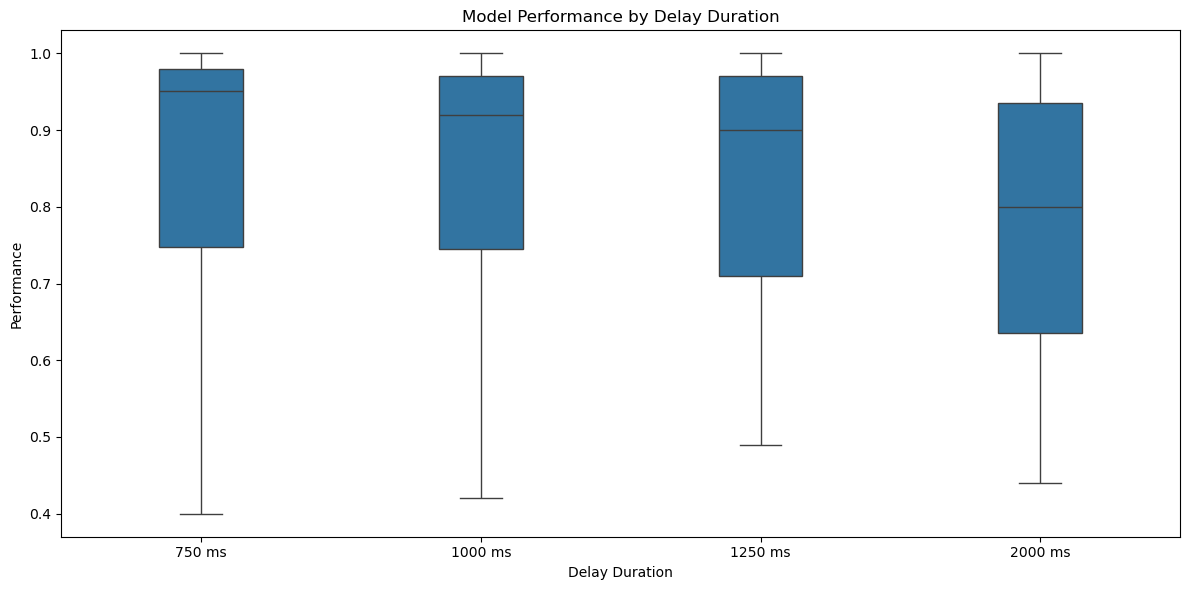

In [72]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd


models_types = ['good_models','bad_models']
lesion_connections_list = ['no lesion', 'I - I','E - E','E - I','I - E']
delays_list = ['', 200, 250, 400]
delays_names = ['750 ms','1000 ms','1250 ms','2000 ms']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located

# Initialize lists to hold data
all_performance = []
all_delays = []

# Loop through the model types and gather data
for i, delays in enumerate(delays_list):
    model_performance = []
    for models_type in models_types:
        this_perf = scipy.io.loadmat(f'{models_dir}{models_type}/{models_type}_performance{delays}.mat')['eval_perf_mean']
        model_performance.append(this_perf)
    model_performance = np.concatenate(model_performance, axis=0)
    
    # Assuming model_performance is structured as (n_models, n_lesions) -- we are only interested in no-lesion performance
    all_performance.extend(model_performance[:, 0])  # Collect performance scores, no lesion
    all_delays.extend([delays_names[i]] * model_performance.shape[0])  # Add model type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Delay Duration': all_delays,
    'Performance': all_performance
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Delay Duration', y='Performance', 
            data=data, width=0.3, dodge=True) 
plt.title('Model Performance by Delay Duration')
plt.xlabel('Delay Duration')
plt.ylabel('Performance')
plt.xticks()
plt.tight_layout()
plt.savefig(f'{final_results_dir}2E.eps', format='eps')
plt.show()


Kruskal-Wallis test statistic: 14.920105547049825, p-value: 0.0018862128724078419


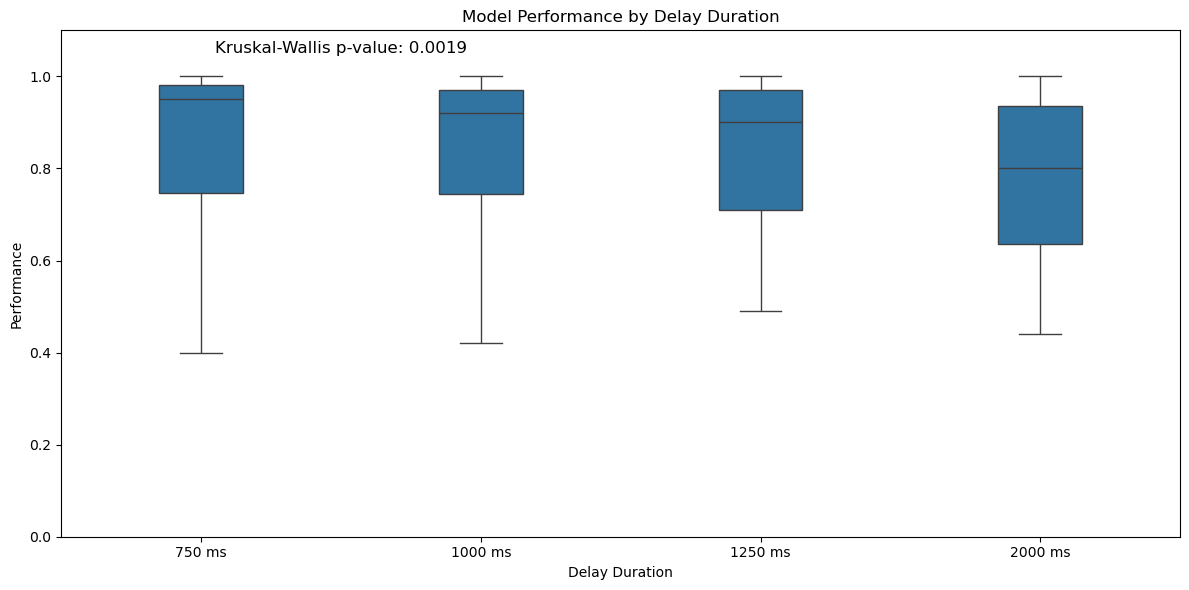

In [33]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd
from scipy import stats


models_types = ['good_models','bad_models']
lesion_connections_list = ['no lesion', 'I - I','E - E','E - I','I - E']
delays_list = ['', 200, 250, 400]
delays_names = ['750 ms','1000 ms','1250 ms','2000 ms']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located

# Initialize lists to hold data
all_performance = []
all_delays = []

# Loop through the model types and gather data
for i, delays in enumerate(delays_list):
    model_performance = []
    for models_type in models_types:
        this_perf = scipy.io.loadmat(f'{models_dir}{models_type}/{models_type}_performance{delays}.mat')['eval_perf_mean']
        model_performance.append(this_perf)
    model_performance = np.concatenate(model_performance, axis=0)
    
    # Assuming model_performance is structured as (n_models, n_lesions) -- we are only interested in no-lesion performance
    all_performance.extend(model_performance[:, 0])  # Collect performance scores, no lesion
    all_delays.extend([delays_names[i]] * model_performance.shape[0])  # Add model type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Delay Duration': all_delays,
    'Performance': all_performance
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Delay Duration', y='Performance', 
            data=data, width=0.3, dodge=True) 
plt.title('Model Performance by Delay Duration')
plt.xlabel('Delay Duration')
plt.ylabel('Performance')
plt.xticks()
plt.ylim([0, 1.1])
plt.tight_layout()

# Perform the Kruskal-Wallis test
delay_groups = [data[data['Delay Duration'] == delay]['Performance'] for delay in delays_names]
kruskal_statistic, kruskal_p_value = stats.kruskal(*delay_groups)
print(f'Kruskal-Wallis test statistic: {kruskal_statistic}, p-value: {kruskal_p_value}')

# Annotate the plot with the test results
y_pos = max(data['Performance']) + 0.05  # Position for annotation
plt.annotate(f'Kruskal-Wallis p-value: {kruskal_p_value:.4f}', 
             xy=(0.5, y_pos), 
             ha='center', 
             fontsize=12, 
             color='black')


# plt.savefig(f'{final_results_dir}2E.eps', format='eps')
plt.show()


## 2G. Differences in high gamma power between 750ms and 2000ms delay in high-performing models

In [35]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
delays_list = ['',400]  # '' if standard delay (150), longer can be 200 or 250

models_type = 'good_models'
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [45]:
# adjust for x-axis labels
t_skips = [20, 30]

In [37]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers.npz
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers_delay400.npz


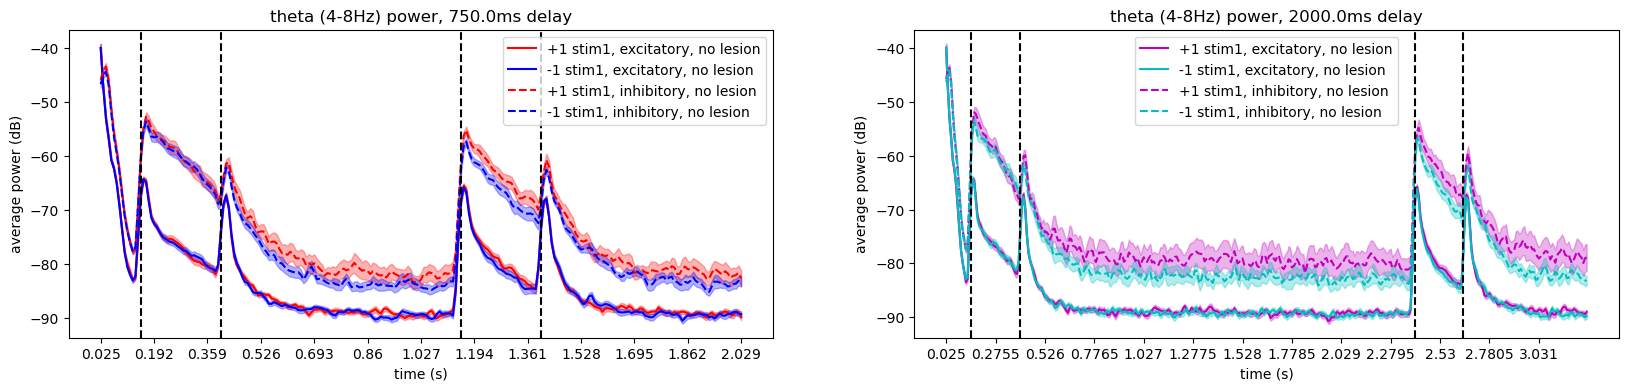

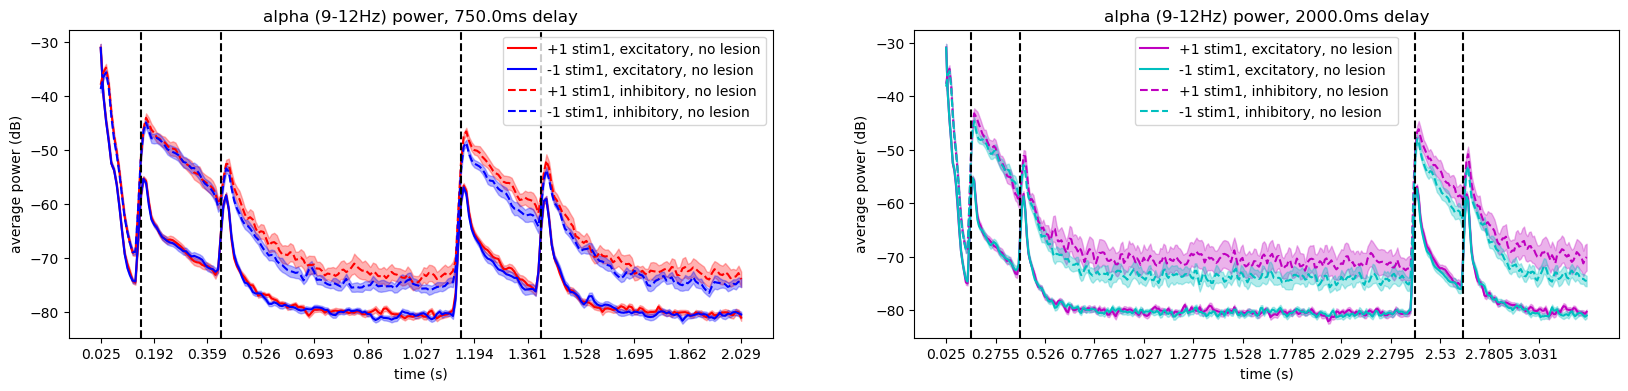

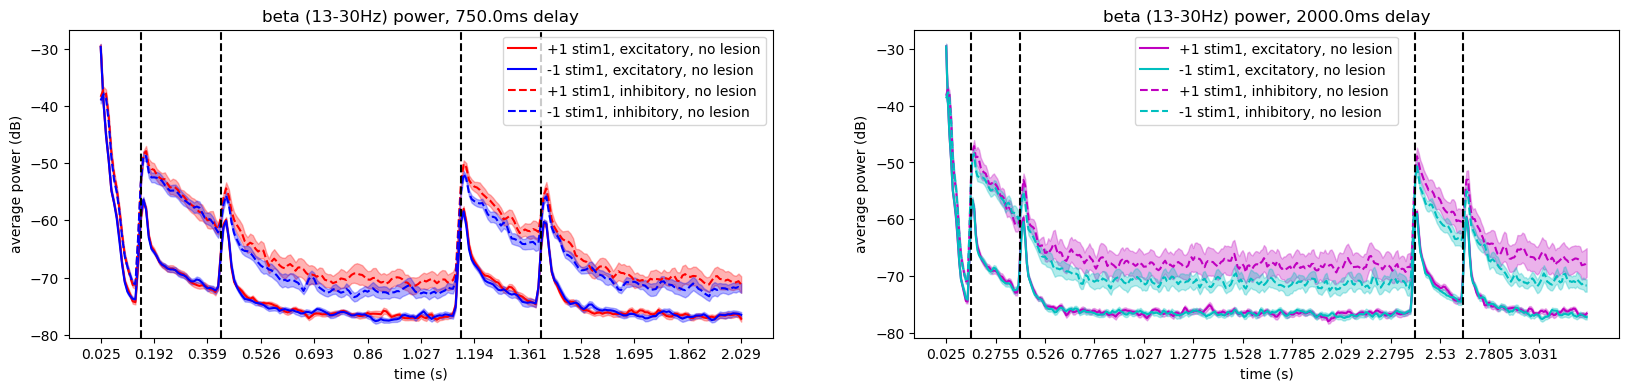

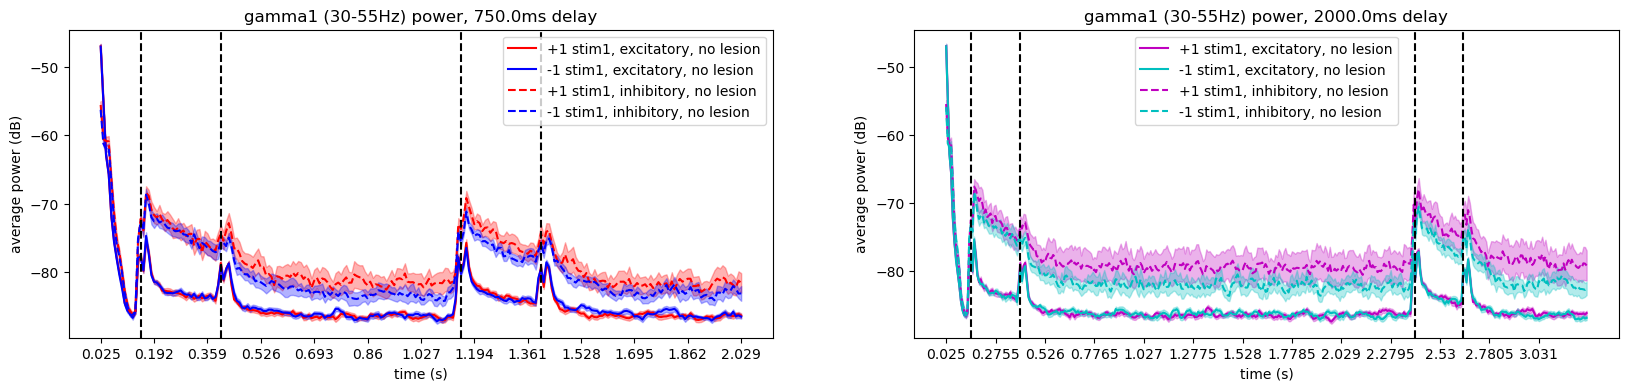

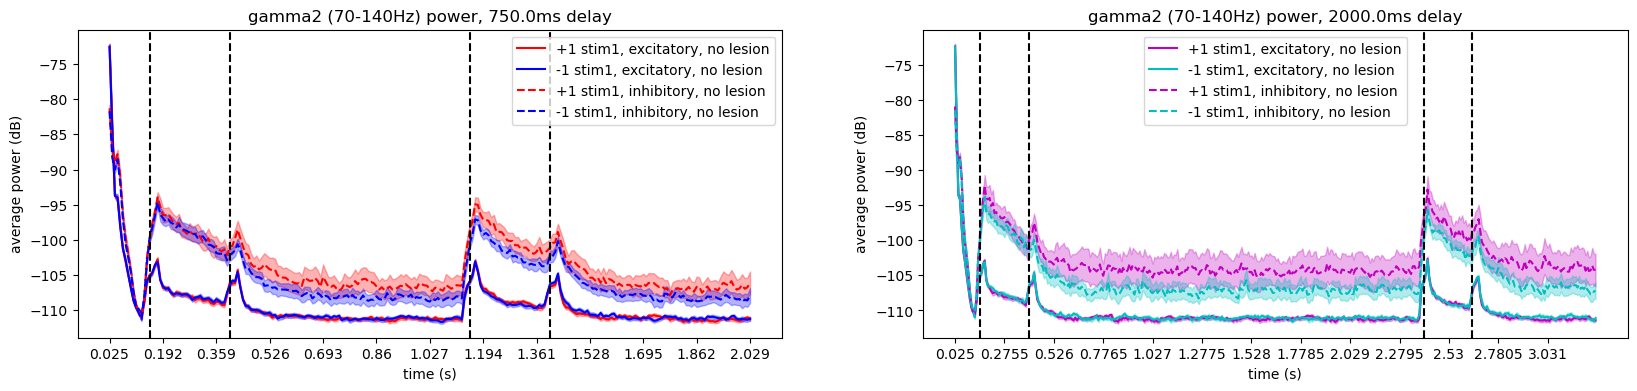

In [46]:
# plot lesioning differences for each power band
delays_list = ['',400]  # '' if standard delay (150), longer can be 200 or 250

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
stim1_on_idx = []
stim1_off_idx = []
stim2_on_idx = []
stim2_off_idx = []
ts = []
for longer_delay in delays_list:

    delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    print(f'loading {results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # load a model to get trial times
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    for n_model, model_fname in enumerate(model_list):
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        break
    
    # get necessary trial timing info 
    ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
    ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
    T = ipsc_data['T'][0][0]
    stim_on = ipsc_data['stim_on'][0][0]
    stim_dur = ipsc_data['stim_dur'][0][0]
    delay = ipsc_data['delay'][0][0]
    fs_rate = 200
    fs_spk = 20000
    del ipsc_data

    # get trial times in real time (seconds)
    stim_on_time = stim_on/fs_rate
    stim_dur_time = stim_dur/fs_rate
    delay_time = delay/fs_rate
    stim1_on = stim_on_time
    stim1_off = stim_on_time + stim_dur_time
    stim2_on = stim_on_time + stim_dur_time + delay_time
    stim2_off = stim_on_time + 2*stim_dur_time + delay_time

    # load spectral time data
    t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))
    ts.append(t)

    # plotting info
    stim1_on_idx.append(np.where(t <= stim1_on)[0][-1])
    stim1_off_idx.append(np.where(t <= stim1_off)[0][-1])
    stim2_on_idx.append(np.where(t <= stim2_on)[0][-1])
    stim2_off_idx.append(np.where(t <= stim2_off)[0][-1])


    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# plot delays on separate plots
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1,2,figsize=(20,4))
    for m, longer_delay in enumerate(delays_list):
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                lesion_connections_list[m] = ['no' if lesion_connections == 0 else lesion_connections][0]
                axs[m].plot(band_mean, label=f'{trial_type} stim1, {neuron_type}, {lesion_connections_list[m]} lesion', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[m].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            # time_vector = np.array(range(0, models_bandmeans[m].shape[3]))
            # _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[m][k][1][:,i,:], # same model, same trial type, inhibitory neurons
            #                                             models_all_powers[m][k][1][:,i,:], 
            #                                             nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            # significant_timepoints = time_vector[pdiff < 0.05]
            # axs[m].scatter(significant_timepoints, np.zeros_like(significant_timepoints)+np.max(models_bandmeans[m][i,j,:,:])+10+k*5, color=colors[j][k], label='_nolegend_', marker='x')
            
        axs[m].axvline(x=stim1_on_idx[m], color='k', linestyle='--')
        axs[m].axvline(x=stim1_off_idx[m], color='k', linestyle='--')
        axs[m].axvline(x=stim2_on_idx[m], color='k', linestyle='--')
        axs[m].axvline(x=stim2_off_idx[m], color='k', linestyle='--')
        axs[m].set_xlabel('time (s)')
        axs[m].set_ylabel('average power (dB)')
        axs[m].set_xticks(range(len(ts[m]))[::t_skips[m]],ts[m][::t_skips[m]])
        for n_delay, delay in enumerate(delays_list):
            if delay == '':
                delays_list[n_delay] = 150
        axs[m].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, {delays_list[m]/200*1000}ms delay')
        axs[m].legend()
    plt.savefig(f'{final_results_dir}2G_{power}_diff_delays.svg', format='svg')


## 2H. Effects of lesioning on model behavioral performance

In [13]:
from scipy import stats

connection type: no lesion, p-value: 8.370002617393648e-12
connection type: I - I, p-value: 0.37812871109544055
connection type: E - E, p-value: 1.251245216672972e-11
connection type: E - I, p-value: 0.0001362424355301749
connection type: I - E, p-value: 1.9455631160407124e-07


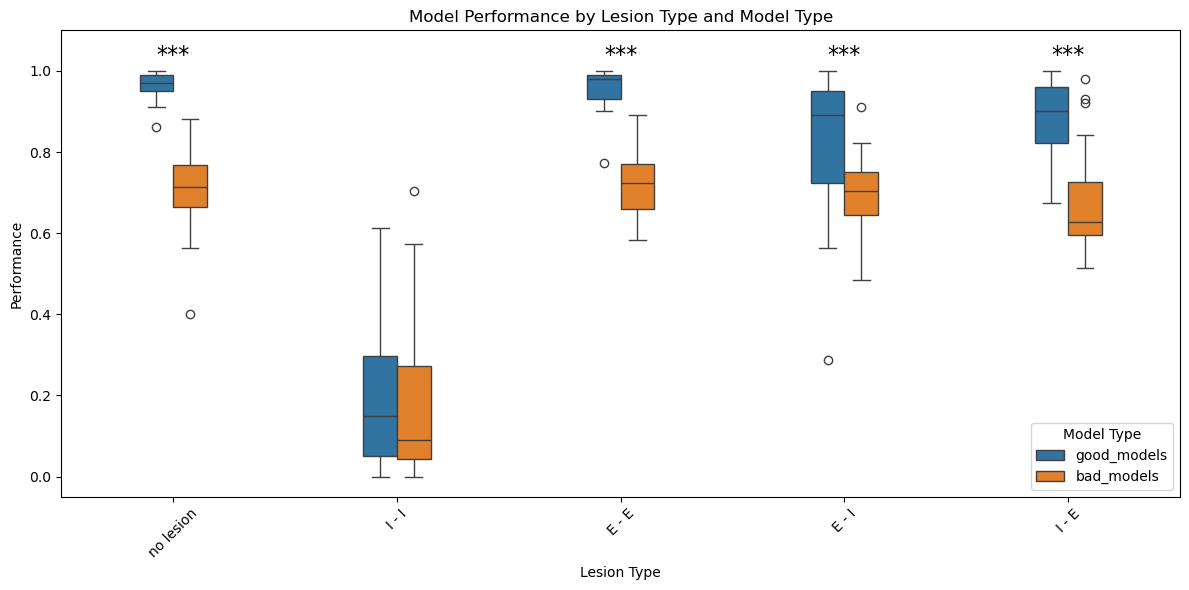

In [22]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd


models_types = ['good_models','bad_models']
lesion_connections_list = ['no lesion', 'I - I','E - E','E - I','I - E']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located

# Initialize lists to hold data
all_performance = []
all_model_types = []
all_lesion_connections = []

# Loop through the model types and gather data
for models_type in models_types:
    model_performance = scipy.io.loadmat(f'{models_dir}{models_type}/{models_type}_performance.mat')['eval_perf_mean']
    
    # Assuming model_performance is structured as (n_models, n_lesions)
    for lesion_idx in range(model_performance.shape[1]):
        all_performance.extend(model_performance[:, lesion_idx])  # Collect performance scores for the lesion type
        all_model_types.extend([models_type] * model_performance.shape[0])  # Add model type for each score
        all_lesion_connections.extend([lesion_connections_list[lesion_idx]] * model_performance.shape[0])  # Add lesion type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Model Type': all_model_types,
    'Lesion Connection': all_lesion_connections,
    'Performance': all_performance
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Lesion Connection', y='Performance', hue='Model Type', 
            data=data, width=0.3, dodge=True) 
plt.title('Model Performance by Lesion Type and Model Type')
plt.xlabel('Lesion Type')
plt.ylabel('Performance')
plt.legend(title='Model Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim([-0.05, 1.1])


# Perform the Wilcoxon rank-sum test between model types for each connection type
for connection_type in lesion_connections_list:
    # Extract weights for the two model types for the current connection type
    group1 = data[(data['Model Type'] == 'good_models') & (data['Lesion Connection'] == connection_type)]['Performance']
    group2 = data[(data['Model Type'] == 'bad_models') & (data['Lesion Connection'] == connection_type)]['Performance']
    
    # Perform the rank-sum test only if both groups have data
    if not group1.empty and not group2.empty:
        statistic, p_value = stats.ranksums(group1, group2)
        print('connection type: {}, p-value: {}'.format(connection_type, p_value))

        # Determine significance level for annotation
        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = ''
        
        # Get the x position for the connection type
        x_pos = lesion_connections_list.index(connection_type)
        
        # Annotate the significance on the plot
        if significance:
            # Adjust y position for the annotation
            y_pos = max(data['Performance']) + 0.01  # Adjust this based on your data
            ax.annotate(significance, 
                        xy=(x_pos, y_pos), 
                        ha='center', 
                        va='bottom', 
                        fontsize=16, 
                        color='black')


# plt.savefig(f'{final_results_dir}1C_with_significance.eps', format='eps')
plt.show()


Comparing good_models no lesion vs no lesion, p-value: 1.0
Comparing good_models no lesion vs I - I, p-value: 6.45063427207173e-15
Comparing good_models no lesion vs E - E, p-value: 0.4838098963354255
Comparing good_models no lesion vs E - I, p-value: 1.261838290967975e-06
Comparing good_models no lesion vs I - E, p-value: 7.302494447564684e-08
Comparing good_models I - I vs no lesion, p-value: 6.45063427207173e-15
Comparing good_models I - I vs I - I, p-value: 1.0
Comparing good_models I - I vs E - E, p-value: 6.45063427207173e-15
Comparing good_models I - I vs E - I, p-value: 3.668656319572383e-14
Comparing good_models I - I vs I - E, p-value: 6.45063427207173e-15
Comparing good_models E - E vs no lesion, p-value: 0.4838098963354255
Comparing good_models E - E vs I - I, p-value: 6.45063427207173e-15
Comparing good_models E - E vs E - E, p-value: 1.0
Comparing good_models E - E vs E - I, p-value: 6.862908743551084e-06
Comparing good_models E - E vs I - E, p-value: 1.1490902424596303e-

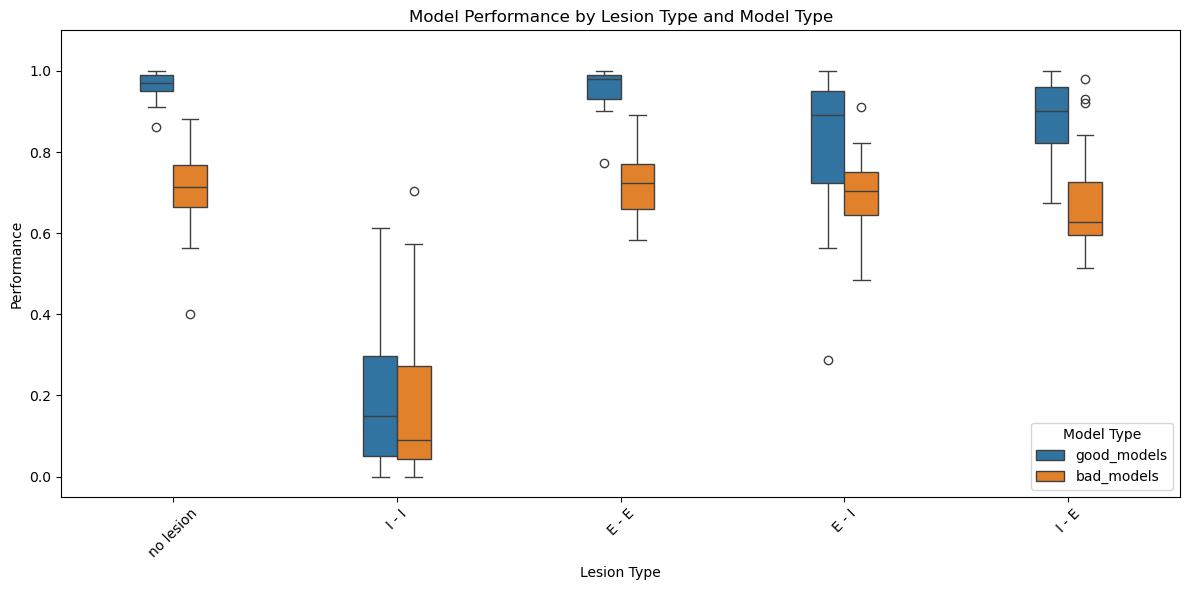

In [30]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd
from scipy import stats

# Define model types and lesion connections
models_types = ['good_models', 'bad_models']
lesion_connections_list = ['no lesion', 'I - I', 'E - E', 'E - I', 'I - E']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/'  # Directory where all models are located

# Initialize lists to hold data
all_performance = []
all_model_types = []
all_lesion_connections = []

# Loop through the model types and gather data
for models_type in models_types:
    model_performance = scipy.io.loadmat(f'{models_dir}{models_type}/{models_type}_performance.mat')['eval_perf_mean']
    
    # Assuming model_performance is structured as (n_models, n_lesions)
    for lesion_idx in range(model_performance.shape[1]):
        all_performance.extend(model_performance[:, lesion_idx])  # Collect performance scores for the lesion type
        all_model_types.extend([models_type] * model_performance.shape[0])  # Add model type for each score
        all_lesion_connections.extend([lesion_connections_list[lesion_idx]] * model_performance.shape[0])  # Add lesion type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Model Type': all_model_types,
    'Lesion Connection': all_lesion_connections,
    'Performance': all_performance
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Lesion Connection', y='Performance', hue='Model Type', 
                 data=data, width=0.3, dodge=True) 
plt.title('Model Performance by Lesion Type and Model Type')
plt.xlabel('Lesion Type')
plt.ylabel('Performance')
plt.legend(title='Model Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim([-0.05, 1.1])

# Perform the Wilcoxon rank-sum test between model types for each lesion type
for model_type in models_types:
    for i, connection1 in enumerate(lesion_connections_list):
        for j, connection2 in enumerate(lesion_connections_list):
    
            # Extract performance for both model types for the current lesion type
            group1 = data[(data['Model Type'] == model_type) & (data['Lesion Connection'] == connection1)]['Performance']
            group2 = data[(data['Model Type'] == model_type) & (data['Lesion Connection'] == connection2)]['Performance']
            
            # Perform the rank-sum test only if both groups have data
            if not group1.empty and not group2.empty:
                statistic, p_value = stats.ranksums(group1, group2)
                print(f'Comparing {model_type} {connection1} vs {connection2}, p-value: {p_value}')

                # # Determine significance level for annotation
                # if p_value < 0.001:
                #     significance = '***'
                # elif p_value < 0.01:
                #     significance = '**'
                # elif p_value < 0.05:
                #     significance = '*'
                # else:
                #     significance = ''
                
                # # Get the x position for the current lesion connection
                # x_pos = lesion_connections_list.index(lesion_connection)
                
                # # Annotate the significance on the plot
                # if significance:
                #     # Adjust y position for the annotation
                #     y_pos = max(data['Performance']) + 0.05  # Adjust this based on your data
                #     ax.annotate(significance, 
                #                 xy=(x_pos, y_pos), 
                #                 ha='center', 
                #                 va='bottom',
                #                 fontsize=16) 

# plt.savefig(f'{final_results_dir}1C_with_significance.eps', format='eps')
plt.show()


## 2I. Effects of I→I lesioning on high gamma power in inhibitory neurons

In [15]:
normalize_ipscs = 1 # usually will be 1
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_type = 'good_models'
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections_list[0] == 0 else f'_lesion{lesion_connections_list[0]}'] #temporary
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [16]:
# load a model to get trial times

models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

for n_model, model_fname in enumerate(model_list):
    
    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    break

Total: 41 good_models models
Loading model 1/41...


In [17]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

# plotting info
stim1_on_idx = np.where(t <= stim1_on)[0][-1]
stim1_off_idx = np.where(t <= stim1_off)[0][-1]
stim2_on_idx = np.where(t <= stim2_on)[0][-1]
stim2_off_idx = np.where(t <= stim2_off)[0][-1]


In [18]:
# adjust for x-axis labels
t_skip = 20

In [19]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers.npz
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers_lesionii.npz


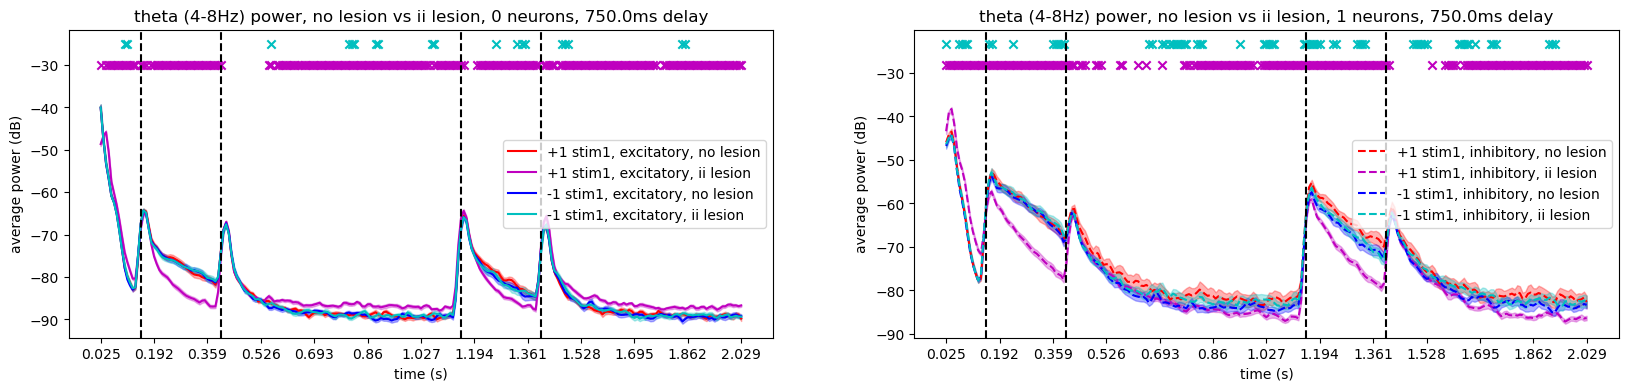

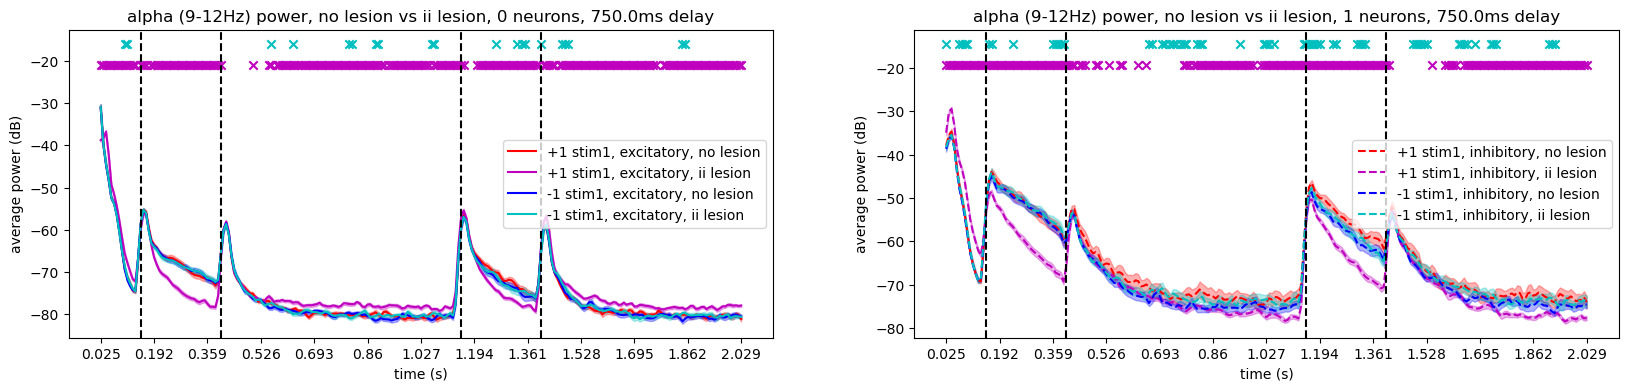

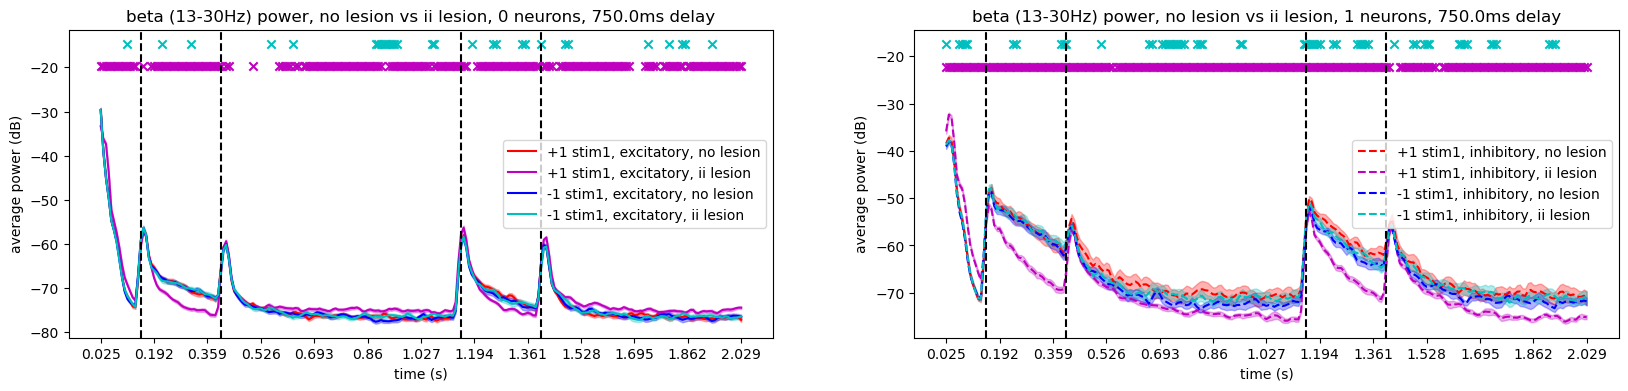

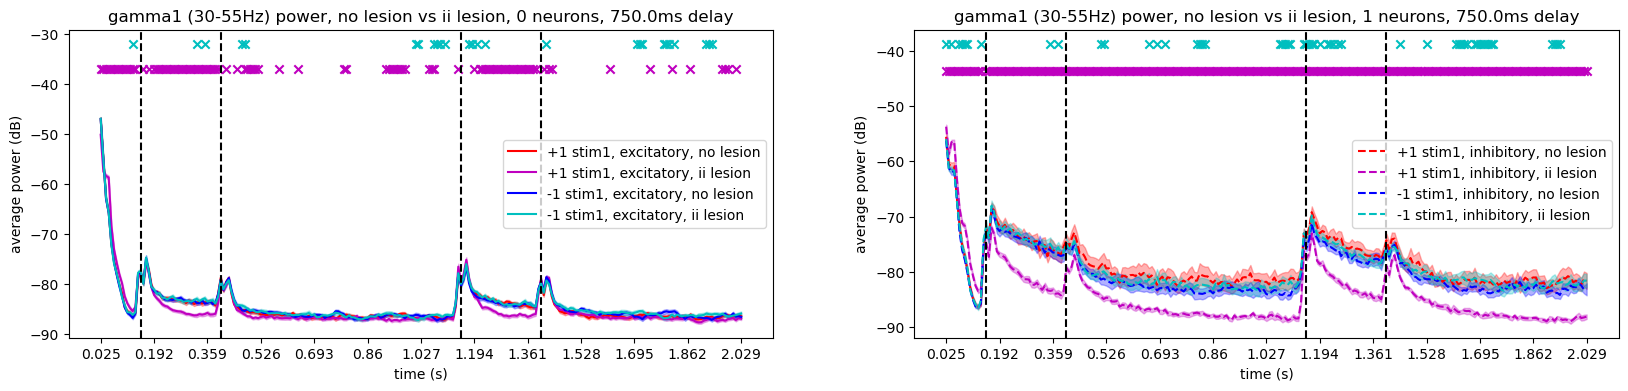

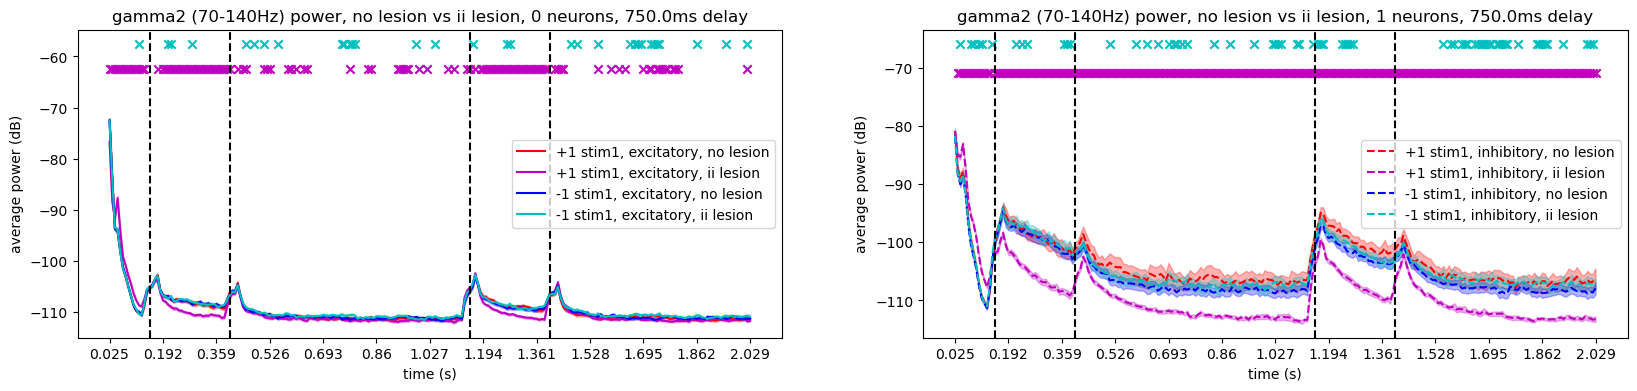

In [20]:
# plot lesioning differences for each power band
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for lesion_connections in lesion_connections_list:

    lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']

    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    print(f'loading {results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# plot no lesion and ii lesion on the same plot
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1,2,figsize=(20,4))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, lesion_connections in enumerate(lesion_connections_list):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                lesion_connections_list[m] = ['no' if lesion_connections == 0 else lesion_connections][0]
                axs[j].plot(band_mean, label=f'{trial_type} stim1, {neuron_type}, {lesion_connections_list[m]} lesion', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[j].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model (lesioning), same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            axs[j].scatter(significant_timepoints, np.zeros_like(significant_timepoints)+np.max(models_bandmeans[m][i,j,:,:])+10+k*5, color=colors[m][k], label='_nolegend_', marker='x')
            
        axs[j].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[j].set_xlabel('time (s)')
        axs[j].set_ylabel('average power (dB)')
        axs[j].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[j].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, no lesion vs {lesion_connections_list[m]} lesion, {j} neurons, {delay/200*1000}ms delay')
        axs[j].legend()
    plt.savefig(f'{final_results_dir}2I_{power}_diff_lesioning.svg', format='svg')


loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers.npz
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers_lesionii.npz


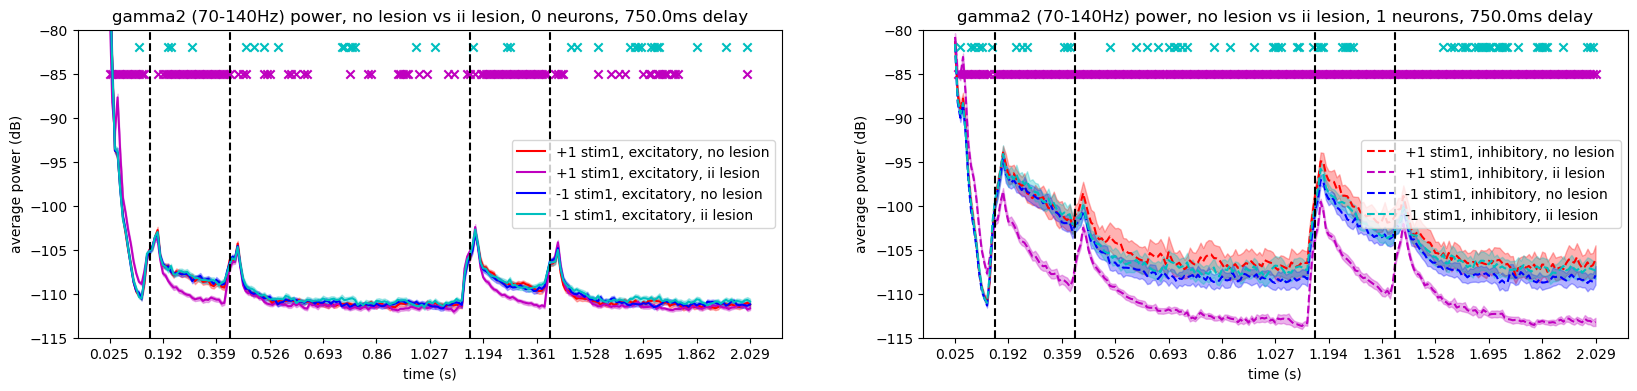

In [31]:
# plot just gamma2
freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

# plot lesioning differences for each power band
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for lesion_connections in lesion_connections_list:

    lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']

    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    print(f'loading {results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# plot no lesion and ii lesion on the same plot
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            continue
            power_range = [4,8]
        elif power == "alpha":
            continue
            power_range = [9,12]
        elif power == "beta":
            continue
            power_range = [13,30]
        elif power == "gamma1":
            continue
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    fig, axs = plt.subplots(1,2,figsize=(20,4))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        for k, trial_type in enumerate(['+1', '-1']):
            for m, lesion_connections in enumerate(lesion_connections_list):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                lesion_connections_list[m] = ['no' if lesion_connections == 0 else lesion_connections][0]
                axs[j].plot(band_mean, label=f'{trial_type} stim1, {neuron_type}, {lesion_connections_list[m]} lesion', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                axs[j].fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model (lesioning), same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            axs[j].scatter(significant_timepoints, np.zeros_like(significant_timepoints)-85+k*3, color=colors[m][k], label='_nolegend_', marker='x')
            
        axs[j].axvline(x=stim1_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim1_off_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_on_idx, color='k', linestyle='--')
        axs[j].axvline(x=stim2_off_idx, color='k', linestyle='--')
        axs[j].set_ylim([-115, -80])
        axs[j].set_xlabel('time (s)')
        axs[j].set_ylabel('average power (dB)')
        axs[j].set_xticks(range(len(t))[::t_skip],t[::t_skip])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        axs[j].set_title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, no lesion vs {lesion_connections_list[m]} lesion, {j} neurons, {delay/200*1000}ms delay')
        axs[j].legend()
    plt.savefig(f'{final_results_dir}2I_{power}_diff_lesioning.svg', format='svg')
